Notebook Author: Steven Camacho

The following notebook presents an incomplete setup of a GA implemented with DEAP utilizing code from the FabSim code for the fitness evaluation of an individual. The individuals in notebook are of a job-based representation, i.e (0,2,1,2,0,0,2,1,1) in the case of 3 unique jobs with 3 operations each. The notebook is organized as follows (Now includes deterministic or random equipment selection options):

* IMPORTANT: download the requirements.txt file into notebook before proceeding
*   Imports & Installs
*   Function to generate jobs, equipments and operations dataframes
*   Scheduler Class
*   Gantt Chart Schedule Visualization function
*   Config object construction example
*   Fitness and Individual generation functions
*   Build GA function - function to build GA environment (missing mutation, crossover and selection genetic operators)
*   Test individual and fitness functions
*   Run GA functions - functions written to run and visualize GA (could possibly need adjusting)
*   Run GA - condensed run code to quickly test and run GA



Imports & Installs

In [111]:
pip install deap


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [137]:
# regular imports used
import random
import numpy as np
import deap
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print("Not running in Google Colab")
import os
from functools import partial
from datetime import datetime
SAVE_DIR = "plots"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

Not running in Google Colab


In [113]:
# imports from fabsim code (make sure to download requirements.txt file)
import pandas as pd
import random
from typing import Tuple, Dict, Any, Union
import numpy as np
import multiprocessing
import copy
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
import time
!pip3 install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
  Using cached absl_py-2.0.0-py3-none-any.whl (130 kB)
  Using cached aiohttp-3.9.5-cp39-cp39-macosx_10_9_x86_64.whl (401 kB)
  Using cached aiosignal-1.2.0-py3-none-any.whl (8.2 kB)
  Using cached anyio-4.2.0-py3-none-any.whl (85 kB)
  Using cached argon2_cffi-21.3.0-py3-none-any.whl (14 kB)
  Using cached attrs-23.2.0-py3-none-any.whl (60 kB)
  Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
  Using cached certifi-2025.1.31-py3-none-any.whl (166 kB)
  Using cached cffi-1.16.0-cp39-cp39-macosx_10_9_x86_64.whl (182 kB)
  Using cached charset_normalizer-2.0.4-py3-none-any.whl (36 kB)
  Using cached click-8.1.7-py3-none-any.whl (97 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl (25 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_10_9_x86_64.whl (265 kB)
  Using cached cryptography-42.0.5-cp39-abi3-macosx_10_12_universal2.whl (5.9 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Usin

In [114]:
# create directory to store GA results
#SAVE_DIR = "/content/drive/MyDrive/FabsimGA_results"
#os.makedirs(SAVE_DIR, exist_ok=True)

In [115]:
# Check version of DEAP
print(deap.__version__)

1.4


Function to generate job, equipment and operation dataframes

In [116]:
def generate_orders(
    number_of_jobs: int,
    number_of_equipment: int,
    number_operation_types: int,
    min_operations: int,
    max_operations: int,
    min_duration: int,
    max_duration: int,
    last_arrival: int,
    equipments=None
):
    """
    Create matrices for jobs, equipments, and operations.
    These would be our "hard-coded" variables for our GA.
    Given problem paramteres relating to # of jobs, equipments, operation types,
    operations per job, duration time, and latest arrival time, dataframes for
    jobs, equipments, and operations are generated.
    The Jobs dataframe pertains to jobs and their details such as the operations they
    hold and what their type is, etc.
    The Equipments dataframe shows what each machine can do in terms of what operations it can process.
    The Operations dataframe only has the purpose of holding info regarding the specifics of the
    operation types, completely separate from the Jobs dataframe.
    The Jobs and Equipments dataframes also hold variables that relate to what is currently going on,
    specifically for this context of a model using reinforcement learning step by step, creating the
    schedule.

    Variables:
    - number_of_jobs: int -> number of jobs to generate
    - number_of_equipment: int -> number of equipment to generate
    - number_operation_types: int -> number of operation types to generate
    - min_operations: int -> minimum number of operations per job
    - max_operations: int -> maximum number of operations per job
    - min_duration: int -> minimum duration of an operation
    - max_duration: int -> maximum duration of an operation
    - last_arrival: int -> latest arrival time for a job
    - equipments: pd.DataFrame -> pre-generated equipment data (if available, not necessary)
    """
    random.seed(42)
    np.random.seed(42)
    # 1. Build or validate equipment table
    # Only if there isnt currently an equipments dataframe
    if equipments is None:

        # If there are more operation types than equipment types, we cannot proceed
        if number_of_equipment < number_operation_types:
            print(f"❌ Too few equipment: {number_of_equipment} < number of operation types: {number_operation_types}")
            sys.exit(1)

        # else continue, we now either have a perfect match or more equipment types (both valid)

        # equipment types will be the range of operation types, i.e. 0, 1
        equipment_op_types = list(range(number_operation_types))

        # check for extra equipment
        extra_equipment = number_of_equipment - number_operation_types
        if extra_equipment > 0:
            equipment_op_types += random.choices(range(number_operation_types), k=extra_equipment) # add k operation type equipment
        random.shuffle(equipment_op_types)

        # Now we would have an array in which the index represents the equipment, and the value would
        # represent what operation type it can process
        # Example for 5 equipments and 3 operation types: equipment_op_types = [1, 0, 0, 2, 1]

        # equipment records will hold each record per equipment
        equipment_records = []


        for eq_id in range(number_of_equipment):
            eq_op = equipment_op_types[eq_id] # get the equipment's operation type

            # create and populate a dictionary to hold equipment records and append to initially declared list
            equipment_records.append({
                "equipment_id": eq_id, # equipment identification
                "operation_id": eq_op, # what operation it can process
                "time": 0.0, # time
                "idle_time_between_jobs": 0.0, # idle time
                "jobs_assigned": [], # jobs assigned
                "assignment_starts": [], # assignment start time
                "assignment_ends": [], # assignment end time
            })

        # create dataframe
        equipments = pd.DataFrame(equipment_records)

        # sort dataframe by equipment identification
        equipments.sort_values(by="equipment_id", inplace=True, ignore_index=True)

    # if we are given an equipments dataframe, we just produce a deep copy and assign it to the dataframe for this function]\;
    else:
        equipments = deepCopy(equipments)

    # 2. Build op_type → equipment map
    # This line creates a dictionary of key: operation type -> value: ids of equipment that process that type of operation
    op_type_to_equip = equipments.groupby("operation_id")["equipment_id"].apply(set).to_dict()

    # Grab the operation types that are supported, i.e. have an equipment that can process it
    supported_op_types = set(op_type_to_equip.keys())

    # 3. Build jobs
    # Create list that will then hold records per job
    jobs_data = []

    # Iterate through each job and fill jobs_data
    for job_id in range(number_of_jobs):
        arrival_t = float(random.randint(0, int(last_arrival))) # Randomly assign arrival time by picking float between 0 and last_arrival variable
        num_ops = random.randint(min_operations, max_operations) # Randomly pick number of operations for job
        ops_seq = random.choices(list(supported_op_types), k=num_ops) # randomly pick the operations that the job will have from the supported op types (create operation sequence)
        dur_seq = [random.randint(min_duration, max_duration) for _ in range(num_ops)] # randomly pick duration for each operation

        # assign dictionary of records for job
        jobs_data.append({
            "job_id": job_id, # job identification
            "arrival_time": arrival_t, # arrival time for job
            "time": arrival_t, # time is also the arrival time
            "operation_time": 0.0, # operation time
            "queue_time": 0.0, # queue time
            "operations": ops_seq, # operations for the job
            "durations": dur_seq, # durations for each operation
            "completed_equipments": [], # completed equipments
            "completed_operations": [], # completed operations
            "assignment_starts": [], # assignment starts
            "assignment_ends": [], # assignment ends
        })

    # make data into dataframe
    jobs = pd.DataFrame(jobs_data)

    # sort by arrival time
    jobs.sort_values(by="arrival_time", inplace=True, ignore_index=True)

    # 4. Build operations table (op_type → equipment mapping)
    # grab operation id and equipment id and reset index to create an index column
    operations = equipments.reset_index()[["operation_id", "equipment_id"]]
    # set operation id as the index, very simple 2 column dataframe
    operations.set_index("operation_id", inplace=True)

    # return the three created dataframes
    return jobs, equipments, operations

Scheduler Class

In [117]:
class Scheduler:
  """
  Scheduler class, created for each individual as it assesses the effectiveness of the proposed
  schedule sequence.
  """

  def __init__(
        self,
        jobs: pd.DataFrame,
        equipments: pd.DataFrame,
        operations: pd.DataFrame,
        num_jobs: int,
        num_equipment: int,
        num_operation_types: int,
        min_operations: int,
        max_operations: int,
        min_duration: int,
        max_duration: int,
        last_arrival: int,
        max_sim_time: int
  ):

    """
    Scheduler class constructor function. It is supposed to take in 3 blank jobs, equipments and operations dataframes
    (consistent randomness for each dataframe, i.e job, operation duration, operation type to equipment assignment),
    additionally takes in all other job, operation, equipment related details (i.e number of jobs, number of operation types)

    Input:
    - jobs: pd.DataFrame -> jobs dataframe
    - equipments: pd.DataFrame -> equipments dataframe
    - operations: pd.DataFrame -> operations dataframe
    - number_of_jobs: int -> number of jobs to generate
    - number_of_equipment: int -> number of equipment to generate
    - number_operation_types: int -> number of operation types to generate
    - min_operations: int -> minimum number of operations per job
    - max_operations: int -> maximum number of operations per job
    - min_duration: int -> minimum duration of an operation
    - max_duration: int -> maximum duration of an operation
    - last_arrival: int -> latest arrival time for a job

    Output:
    - creates sheduler object
    """
    self.jobs = jobs
    self.equipments = equipments
    self.operations = operations
    self.num_jobs = num_jobs
    self.num_equipment = num_equipment
    self.num_operation_types = num_operation_types
    self.min_operations = min_operations
    self.max_operations = max_operations
    self.min_duration = min_duration
    self.max_duration = max_duration
    self.last_arrival = last_arrival
    self.max_sim_time = max_sim_time
    self.total_duration = -1
    self.remaining_total_duration = -1
    self.unfinished_operations = 0

  def prepare_scheduler(self):
    """
    Scheduler initiation helper function. It will add variables necessary for future computation of schedule effectiveness.

    Input:
    - access to the scheduler object previously created

    Output:
    - variables added to the scheduler object:
      - wip_job_ids = work in progress job ids
      - job_ops_list = list of operations for each job (immutable)
      - job_durations_list = list of durations for each job (immutable)
      - job_current_op_index = current operation index for each job
      - done = flag variable for when schedule is done being assessed
      - last_time = the time clocked for the last operation on the schedule,
        added up from previous schedule operations, should be equivalent to makespan
      - op_to_equip = dictionary of operation to equipment mapping (immutable)
      - job_index_map =
      - equip_index_map =
      - unfinished_operations = starts off with operation quantity length of each job, gets reduced as operations are completed
      - total_operations = total number of operations (immutable)
      - total_duration = length of operations added up to represent total duration of the job (immutable)
      - remaining_total_duration = length of duration of job with subtractions being done for each operation that is completed
      - available_time =
    """

    self.wip_job_ids = set(self.jobs.index)
    self.job_ops_list = [row["operations"][:] for _, row in self.jobs.iterrows()]
    self.job_durations_list = [row["durations"][:]  for _, row in self.jobs.iterrows()]
    self.job_current_op_index = [0]*self.num_jobs
    self.done = False
    self.last_time = 0.0

    # Precompute operation -> [equipment IDs] (no repeated DataFrame calls)
    self.op_to_equip = {}
    for new_eq_idx, row in self.equipments.iterrows():
      op_id = row["operation_id"]
      if op_id not in self.op_to_equip:
          self.op_to_equip[op_id] = []
      self.op_to_equip[op_id].append(new_eq_idx)

    self.job_index_map   = {job_id: i for i, job_id in enumerate(self.jobs.index)}
    self.equip_index_map = {eq_id:  j for j, eq_id in enumerate(self.equipments.index)}

    self.unfinished_operations = self.jobs["operations"].apply(len).sum()
    self.total_operations = self.unfinished_operations
    self.total_duration = self.jobs["durations"].apply(sum).sum()
    self.remaining_total_duration = self.total_duration
    self.available_time = 0.0

  def find_matching_equipment(self, job_id: int, flag: bool=False)->int:
    """
    Function to find matching equipment for job
    So far, no optimization for when machine is available,
    main purpose of function is just find a match in terms of
    equipment that can complete the operation from the job

    Input:
    - access to the scheduler object previously created
    - job_id = job id in question at current point in individual sequence

    Output:
    - equip_id = matching equipment id that can process whatever needed operation type from job
    """
    #print("#################FINDING MATCHING EQUIPMENT###################")
    attempts = 0

    # get total jobs in progress
    total = len(self.wip_job_ids)
    #print("# total jobs in progress:\n")
    #print(total)

    # get the current operation up next from job
    op_idx = self.job_current_op_index[job_id]
    #print("# current operation index:\n")
    #print(op_idx)

    # if operation index from job is less than the length of operations from a job, proceed
    if op_idx < len(self.job_ops_list[job_id]):
        #print("# operation index from job is less than the length of operations from a job")
        # get the operation type of the operation that is up next
        needed_op = self.job_ops_list[job_id][op_idx]
        #print("## operation type:\n")
        #print(needed_op)
    else:
        #print("# operation index from job is greater than the length of operations from a job, job is done")
        # job is actually done
        self.wip_job_ids.remove(job_id)

        # if no work in progress jobs left, return None
        #print("## quantity of jobs still in progress\n")
        #print(len(self.wip_job_ids))
        if len(self.wip_job_ids) == 0:
            return None

    # extra check if the operation index surpasses the length of operations from
    # a job and there is still work in progress left, return None
    if op_idx >= len(self.job_ops_list[job_id]):
      #print("# operation index surpasses the length of operations from a job and there is still work in progress left, return None")
      return None

    # from the operations table, grab the rows that correspond to the operation type specified
    valid_ops_rows = self.operations.loc[[needed_op]]
    #print("# valid operations rows from operations table:\n")
    #print(valid_ops_rows)

    # find possible equipment that can do needed_op
    candidate_equip_ids = [
      eid for eid in valid_ops_rows["equipment_id"].tolist()
        if eid in self.equipments.index
    ]

    candidate_equip_ids = sorted(
      candidate_equip_ids,
      key=lambda eid: self.equipments.loc[eid, "time"]
    )
    #print("# candidate equipment ids from the valid operation rows:\n")
    #print(candidate_equip_ids)
    #print(self.equipments)
    # if no equipment id found to be able to do operation, return None
    if not candidate_equip_ids:
      #print("# no equipment id found to be able to do operation, return None")
      return None

    # This is the part that would be optimized if we were to incorporate some sort of search to take advantage of idle time
    # for now, pick random equipment from candidate list
    # add a flag
    # if flag yes
    # pick the machine with the earliest end time for current or last operation
    #print("flag\n")
    #print(flag)
    if flag:
      #print("Deterministic machine choice")
      equip_id = candidate_equip_ids[0]
    else:
      #print("Random machine choice")
      equip_id = random.choice(candidate_equip_ids)

    #print("# chosen equipment id:\n")
    #print(equip_id)
    #print("################################################################")
    return equip_id

  def step(
          self,
          job_id: int,
          flag: bool = False
  ) -> int:
    """
    step function represents our fitness assessment method for an individual. This function will be iteratively called
    on each gene from the individual, i.e each job id found in the job-based sequence.


    Input:
    - access to the scheduler object previously created
    - job_id = job id in question at current point in individual sequence

    Output:
    - self.available_time = makespan calculation at current point in individual sequence
    """
    #print("#################STEP###################")
    #print("# job id:\n")
    #print(job_id)

    equip_id = self.find_matching_equipment(job_id, flag)
    #print("# equipment id:\n")
    #print(equip_id)
      # define info dictionary that will account for validity in the following:
      # - is the job id in range?
      # - is the equipment id in range?
      # - any empty operations?
      # - operation match?
      # - truncated? as in the schedule becomes invalid.
    info = {
        "check_job_id_in_range": False,
        "check_equipment_id_in_range": False,
        "check_not_empty_operations": False,
        "check_operations_match": False,
        "truncated": False
      }

    # Initial validation checks
    failed_checks = 0

    # is the given job id a valid id?
    if job_id not in self.jobs.index:
        #print("# job id not in range")
        failed_checks += 1

    # is the given equipment id a valid id?
    if equip_id not in self.equipments.index:
        #print("# equipment id not in range")
        failed_checks += 1

    # something is not valid, cancel entire process
    if failed_checks > 0:
        #print("# something is not valid from initial validation checks")
        self.done = True
        truncated = True
        info["truncated"] = True

        # adjust what is returned
        return self.done, truncated, info

    # Get job and equipment references from dataframes
    job_row = self.jobs.loc[job_id] # get job row
    #print("# job row:\n")
    #print(job_row)

    eq_row = self.equipments.loc[equip_id] # get equipment row
    #print("# equipment row:\n")
    #print(eq_row)

    # get the current operation from the job (at the start that will be 0)
    op_idx = self.job_current_op_index[job_id]
    #print("# current operation index:\n")
    #print(op_idx)

    # Operation validation
    # check if the index of the operation is out of bounds from the operation array from the job
    if op_idx >= len(self.job_ops_list[job_id]):
        failed_checks += 1
        #print("# operation index is out of bounds from the operation array from the job")
    else:
      # get operation type
      needed_op = self.job_ops_list[job_id][op_idx]
      #print("# operation type:\n")
      #print(needed_op)

    # if operation type does not match the equipment type, fail
    if eq_row["operation_id"] != needed_op:
        #print("# operation type does not match the equipment type")
        failed_checks += 1

    # something is not valid from operation validation
    if failed_checks > 0:
        # print("# something is not valid from operation validation")
        self.done = True
        truncated = True
        info["truncated"] = True
        return self.done, truncated, info

    # Scheduling logic
    job_old_time = job_row["time"] # grab the old time of the job (time when whatever operation from job happened beforehand ends)
    #print("# when jobs current or past operations ends/ended:\n")
    #print(job_old_time)

    #print("# when equipment is next available:\n")
    #print(eq_row["time"])

    scheduled_time = max(job_row["time"], eq_row["time"]) # pick the larger of times between job and equipment
    #print("# longer time between the two (will be starting time for current operation):\n")
    #print(scheduled_time)

    current_duration = self.job_durations_list[job_id][op_idx] # grab the duration of the operation from the job
    #print("# current operation duration:\n")
    #print(current_duration)

    self.available_time = scheduled_time + current_duration # available time is the larger of times between job and equipment + the duration of the operation
    #print("# when operation can be started + duration = end time (makespan) at this current point:\n")
    #print(self.available_time)

    # update job time (when current operation of job finishes, aka can proceed in job operation array)
    self.jobs.at[job_id, "time"] = self.available_time
    #print("# new time for when job will be able to pass its next operation:\n")
    #print(self.jobs.at[job_id, "time"])

    # update equipment time (when equipment is next available)
    self.equipments.at[equip_id, "time"] = self.available_time
    #print("# new time for when equipment will be available:\n")
    #print(self.equipments.at[equip_id, "time"])

    # Record assignment history
    self.equipments.at[equip_id, "assignment_starts"].append(scheduled_time)
    self.equipments.at[equip_id, "assignment_ends"].append(self.available_time)

    # add job to equipment record
    self.equipments.at[equip_id, "jobs_assigned"].append(job_id)

    # Advance operation pointer
    self.job_current_op_index[job_id] += 1
    #print("# new current operation index:\n")
    #print(self.job_current_op_index[job_id])

    # check if job is now finished
    if self.job_current_op_index[job_id] >= len(self.job_ops_list[job_id]):
        #print("# job is now finished")
        # job is actually done
        self.wip_job_ids.remove(job_id)

    #print("# makespan:\n")
    #print(self.available_time)

    #print("####################################################")
    # return available time
    return self.available_time

Gantt Chart function - visualize schedule

In [118]:
def plot_gantt_chart(equipments: pd.DataFrame, counter: int):
    """
    Creates a Gantt chart based on the equipments DataFrame.
    """
    unique_jobs = set()
    for _, row in equipments.iterrows():
        jobs_assigned = row.get("jobs_assigned", [])
        if isinstance(jobs_assigned, list):
            unique_jobs.update(jobs_assigned)
    unique_jobs = sorted(unique_jobs)

    cmap = mpl.cm.get_cmap('tab20', len(unique_jobs))
    job_colors = {job: cmap(i) for i, job in enumerate(unique_jobs)}

    max_end_time = 0
    for _, row in equipments.iterrows():
        ends = row.get("assignment_ends", [])
        if isinstance(ends, list) and len(ends) > 0:
            max_end_time = max(max_end_time, max(ends))

    plt.figure(figsize=(12, 8))
    for equip_id, row in equipments.iterrows():
        jobs_assigned = row.get("jobs_assigned", [])
        starts = row.get("assignment_starts", [])
        ends = row.get("assignment_ends", [])
        if not (isinstance(jobs_assigned, list) and len(jobs_assigned) > 0):
            continue
        for job, start, end in zip(jobs_assigned, starts, ends):
            duration = end - start
            color = job_colors.get(job, 'gray')
            plt.barh(
                y=equip_id, width=duration, left=start, height=0.4,
                align='center', color=color, alpha=0.8, edgecolor='black'
            )
            plt.text(
                x=start + duration/2, y=equip_id,
                s=str(job), va='center', ha='center', color='white', fontsize=8
            )

    sorted_equips = sorted(equipments.index)
    for eq in sorted_equips:
        plt.axhline(y=eq + 0.5, color='black', linestyle='-', linewidth=1)
        plt.axhline(y=eq - 0.5, color='black', linestyle='-', linewidth=1)

    plt.xlabel("Time")
    plt.ylabel("Equipment ID")
    plt.title("Gantt Chart of Equipment Assignments")
    plt.xlim(0, max_end_time + 5)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{counter}_gantt_chart.png", bbox_inches='tight')
    plt.show()

Config object construction example for next section

In [119]:
'''
config = {
    "NUM_JOBS": 3,
    "NUM_EQUIPMENT": 3,
    "NUM_OP_TYPES": 3,
    "MIN_OPERATIONS": 3,
    "MAX_OPERATIONS": 3,
    "MIN_DURATION": 1,
    "MAX_DURATION": 4,
    "LAST_ARRIVAL": 0,
    "MAX_SIM_TIME": 15
}
'''

'\nconfig = {\n    "NUM_JOBS": 3,\n    "NUM_EQUIPMENT": 3,\n    "NUM_OP_TYPES": 3,\n    "MIN_OPERATIONS": 3,\n    "MAX_OPERATIONS": 3,\n    "MIN_DURATION": 1,\n    "MAX_DURATION": 4,\n    "LAST_ARRIVAL": 0,\n    "MAX_SIM_TIME": 15\n}\n'

Fitness and individual functions

In [120]:
scheduler_cache = {}

In [121]:
def fitness_wrapper(individual, config, flag, scheduler_cache):
  jobs, equipment, operations = generate_orders(config["NUM_JOBS"], config["NUM_EQUIPMENT"], config["NUM_OP_TYPES"], config["MIN_OPERATIONS"], config["MAX_OPERATIONS"], config["MIN_DURATION"], config["MAX_DURATION"], config["LAST_ARRIVAL"])
  scheduler = Scheduler(jobs, equipment, operations, config["NUM_JOBS"], config["NUM_EQUIPMENT"], config["NUM_OP_TYPES"], config["MIN_OPERATIONS"], config["MAX_OPERATIONS"], config["MIN_DURATION"], config["MAX_DURATION"], config["LAST_ARRIVAL"], config["MAX_SIM_TIME"])
  scheduler.prepare_scheduler()
  for j in individual:
    scheduler.step(j, flag)
  #plot_gantt_chart(scheduler.equipments)
  makespan = scheduler.jobs['time'].max()

  key = tuple(individual)
  scheduler_cache[key] = scheduler.equipments.copy()
  
  return (makespan, )

In [122]:
def gen_individual(k, n):
  np.random.seed(None)
  arr = np.repeat(np.arange(k), n)
  np.random.shuffle(arr)
  return arr.tolist()

Build GA function

In [123]:
def fill_remaining(child, donor, job_set):
    donor_filtered = [job for job in donor if job in job_set]
    
    j=0
    for i in range(len(child)):
        if child[i] is None and j < len(donor_filtered):
            child[i] = donor_filtered[j]
            j += 1


def make_crossover(config):
    num_jobs = config["NUM_JOBS"]
    jobs = list(range(num_jobs))
    random.shuffle(jobs)
    mid = num_jobs // 2
    J1 = jobs[:mid]
    J2 = jobs[mid:]
    #print(f"J1: {J1}, J2: {J2}")
    def pox_crossover(ind1, ind2):
        C1 = [None] * len(ind1)
        C2 = [None] * len(ind2)

        for i in range(len(ind1)):
            if ind1[i] in J1:
                C1[i] = ind1[i]
        
        for i in range(len(ind2)):
            if ind2[i] in J2:
                C2[i] = ind2[i]

        #print(f"C1 after copying: {C1}")
        #print(f"C2 after copying: {C2}")
        fill_remaining(C1, ind2, J2)
        fill_remaining(C2, ind1, J1)
        #print(f"C1 after filling remaining: {C1}")
        #print(f"C2 after filling remaining: {C2}")
        ind1[:] = C1
        ind2[:] = C2

        return ind1, ind2
    
    return pox_crossover

In [124]:
config = {
    "NUM_JOBS": 4
}

pox = make_crossover(config)

parent1 = [3, 2, 0, 3, 1, 2, 0, 3, 1, 3, 2, 2, 0, 1, 1, 0]
parent2 = [2, 3, 0, 2, 1, 3, 2, 0, 1, 3, 3, 1, 0, 1, 2, 0]

child1, child2 = pox(parent1[:], parent2[:])  # use copies

print("Parent1:", parent1)
print("Parent2:", parent2)
print("Child1 :", child1)
print("Child2 :", child2)

Parent1: [3, 2, 0, 3, 1, 2, 0, 3, 1, 3, 2, 2, 0, 1, 1, 0]
Parent2: [2, 3, 0, 2, 1, 3, 2, 0, 1, 3, 3, 1, 0, 1, 2, 0]
Child1 : [3, 2, 0, 3, 1, 2, 2, 3, 1, 3, 0, 0, 2, 1, 1, 0]
Child2 : [2, 3, 0, 2, 3, 1, 2, 0, 3, 1, 3, 1, 0, 1, 2, 0]


In [125]:
def build_ga(gen_individual, fitness_wrapper, config, flag, scheduler_cache):

  # ========== DEFINE SEARCH SPACE ==========


  # ========== CREATE CLASSES ==========
  # creator.create used to create classes, weights used to determine minimize or maximize metric, in this case loss
  # DEAP designed to handle multi-objective optimization = use of tuples, fitness function should return tuple
  # set whether we want to find max best or worst fitness (1.0, ) = max, (-1.0, ) = min
  if not hasattr(creator, "FitnessMin"):
    creator.create(
                  "FitnessMin", #name
                  base.Fitness,
                  weights=(-1.0,)
                  )    # set whether we want to find max best or worst fitness (1.0, ) = max, (-1.0, ) = min

  if not hasattr(creator, "Individual"):
    creator.create(
                  "Individual",
                  list,
                  fitness=creator.FitnessMin
                  )    # define the individual type, fitness type attached to individual to assess

  # ========== TOOLBOX ==========
  # toolbox = container of functions
  toolbox = base.Toolbox()    # toolbox where we can register functions that build and manipulate individuals

  # function to create individual, i.e [0,1,2,2,1,0,0,1,2], 3 jobs and 3 operations each
  toolbox.register(
      "individual_gen", # name for the function that generates the list of genes
      gen_individual, # function to generate one gene
      k= config["NUM_JOBS"], # number of unique jobs
      n= config["MIN_OPERATIONS"] # how many operations each job has (given that each job has the same number of operations)
    )

  # use above function to create individual and attach individual class to it
  toolbox.register(
    "individual",
    tools.initIterate,
    creator.Individual,
    toolbox.individual_gen
  )

  # function to create population
  toolbox.register(
      "population", # name
      tools.initRepeat, # mechanism to run, e.g run the following whatever k times, inputs are below,
      # population size given later, since we decide population size at run time
      list, # container type
      toolbox.individual, # function to run
      )

  # fitness
  toolbox.register(
      "evaluate", # name
      fitness_wrapper, # function to be used
      config=config,
      flag=flag, 
      scheduler_cache=scheduler_cache
      )

  # Genetic Operator Setup

  # function for selection
  toolbox.register(
      "select",
      tools.selTournament,
      tournsize=config["tournsize"]
  )
  
  # Crossover function, crossover rate given at run time because it is used for entire individuals
  toolbox.register(
      "mate",
      make_crossover(config)
  )
  
  # Mutation Function
  toolbox.register(
      "mutate",
      tools.mutShuffleIndexes,
      indpb=config["INDPB"]
  )

  return toolbox


Test individual and fitness functions

In [126]:
# Use the scheduling configuration for this test
"""
config_scheduling = {
    "NUM_JOBS": 3,
    "NUM_EQUIPMENT": 3,
    "NUM_OP_TYPES": 3,
    "MIN_OPERATIONS": 3,
    "MAX_OPERATIONS": 3,
    "MIN_DURATION": 1,
    "MAX_DURATION": 4,
    "LAST_ARRIVAL": 0,
    "MAX_SIM_TIME": 15,
    "CXPB": 0.5,
    "MUTPB": 0.02,
    "INDPB": 0.02,
    "tournsize": 2,
    "NUM_RUNS": 5,
    "POP_SIZE": 100,
    "NGEN": 100,
}

flag = True
toolbox = build_ga(gen_individual, fitness_wrapper, config_scheduling, flag)
individual = toolbox.individual()
print(individual)
fitness = toolbox.evaluate(individual)
print(fitness)
"""


'\nconfig_scheduling = {\n    "NUM_JOBS": 3,\n    "NUM_EQUIPMENT": 3,\n    "NUM_OP_TYPES": 3,\n    "MIN_OPERATIONS": 3,\n    "MAX_OPERATIONS": 3,\n    "MIN_DURATION": 1,\n    "MAX_DURATION": 4,\n    "LAST_ARRIVAL": 0,\n    "MAX_SIM_TIME": 15,\n    "CXPB": 0.5,\n    "MUTPB": 0.02,\n    "INDPB": 0.02,\n    "tournsize": 2,\n    "NUM_RUNS": 5,\n    "POP_SIZE": 100,\n    "NGEN": 100,\n}\n\nflag = True\ntoolbox = build_ga(gen_individual, fitness_wrapper, config_scheduling, flag)\nindividual = toolbox.individual()\nprint(individual)\nfitness = toolbox.evaluate(individual)\nprint(fitness)\n'

From this point, the focus is on running the genetic algorithm at this point 12/14/2025, further adjustment needs to be made to account for our specific problem representation

Run GA functions

In [127]:
def run_ga(toolbox, config, scheduler_cache, seed=None, flag=False):

    # ensure reproducibility random seed
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # create population
    pop = toolbox.population(n=config['POP_SIZE'])

    # HallOfFame for the best individual seen in run, (1)=keep only one of them, best one
    hof = tools.HallOfFame(1)

    # define what statistics are desired, compute stats for ga run
    # pick first value of fitness tuple
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])   # define where to grab data, extract first value of fitness from each individual in the population

    # perform following statistic measures on recorded fitness levels of curr generation
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # ga algorithm runs
    final_pop, logbook = algorithms.eaSimple(
        pop, toolbox,   # population and toolbox
        cxpb=config['CXPB'], mutpb=config['MUTPB'],   #crossover and mutation probabilities
        ngen=config['NGEN'], stats=stats,   # num of generations and statistics to collect
        halloffame=hof, verbose=False   # halloffame to track best individuals seen during evolution, verbose (suppress or allow printed output)
    )

    # final_pop is returned as the final evolved population, logbook is a logbook containing all recorded stats for each generation

    # Extract per-generation fitness values
    # logbook.select(key) = list of stats per generation
    gen_best = logbook.select("min")   # list of best fitness each generation
    gen_avg = logbook.select("avg")    # list of avg fitness each generation

    # Best fitness value
    final_best = hof[0].fitness.values[0]

    # Best individual overall
    best_ind = hof[0]
    best_key = tuple(best_ind)

    best_equipments = scheduler_cache.get(best_key)

    return {
        "logbook": logbook,                # full logbook (for plotting)
        "gen_best": gen_best,      # list of best fitness per generation
        "gen_avg": gen_avg,        # list of average fitness per generation
        "final_best": final_best,  # best fitness at the end
        "best_individual": best_ind,  # coefficients [a,b,c,d,e]
        "best_pair": [best_ind, final_best],
        "best_equipments": best_equipments
    }

In [128]:
def run_experiment(toolbox, config, flag, scheduler_cache):
  results = []  # store results, list to hold output of each GA run
  BASE_SEED = 42  # set base seed for replicable experiments when changing

  for r in range(config['NUM_RUNS']):   # 50 GA runs
    # set seed for reproducibility
    seed=BASE_SEED + r

    # run the GA
    run_data = run_ga(toolbox, config, scheduler_cache, seed, flag)

    # Append results
    results.append(run_data)

  return results

In [129]:
def get_best_coefficients(results):
  pairs = [r["best_pair"] for r in results]
  best_cos = sorted(pairs, key=lambda x: x[1])[0]
  return best_cos[0]


In [130]:
"""
def visualize_individual(config, individual):
  F_MIN = config['F_MIN']
  F_MAX = config['F_MAX']
  X = np.linspace(F_MIN, F_MAX, 100)
  true = config['true']
  Y = true[0]*X**2 - true[1]*X + true[2] + true[3]*np.cos(X) - true[4]*np.sin(X) # get Y labels

  a, b, c, d, e = individual
  y2 = a*X**2 - b*X + c + d*np.cos(X) - e*np.sin(X) # get Y labels

  plt.plot(X, Y, label="Line 1 (Target)", linewidth=2)
  plt.plot(X, y2, label="Line 2 (Prediction)", linewidth=2, linestyle='--')
  plt.title("Predicted Curve vs True Curve")
  plt.legend()
  plt.show()

  print(f"Predicted Coefficients: {individual}")
"""


'\ndef visualize_individual(config, individual):\n  F_MIN = config[\'F_MIN\']\n  F_MAX = config[\'F_MAX\']\n  X = np.linspace(F_MIN, F_MAX, 100)\n  true = config[\'true\']\n  Y = true[0]*X**2 - true[1]*X + true[2] + true[3]*np.cos(X) - true[4]*np.sin(X) # get Y labels\n\n  a, b, c, d, e = individual\n  y2 = a*X**2 - b*X + c + d*np.cos(X) - e*np.sin(X) # get Y labels\n\n  plt.plot(X, Y, label="Line 1 (Target)", linewidth=2)\n  plt.plot(X, y2, label="Line 2 (Prediction)", linewidth=2, linestyle=\'--\')\n  plt.title("Predicted Curve vs True Curve")\n  plt.legend()\n  plt.show()\n\n  print(f"Predicted Coefficients: {individual}")\n'

In [131]:
def transform_res(results, config):
  # create matrix holding the best fitness from each generation per run
  gen_best_matrix = np.array([r["gen_best"] for r in results])  # r["gen_best"] is a list the best fitness from each generation (0-100) from a single run

  # create matrix the average fitness accross the population from each generation per run
  gen_avg_matrix = np.array([r["gen_avg"] for r in results]) # r["gen_avg"] is a list the average population fitness from each generation (0-100) from a single run

  # mean best across runs, mean best fitness per generation
  mean_best_per_gen = np.mean(gen_best_matrix, axis=0)

  # standard deviation across generations, mean best fitness per run, variability across runs
  std_best_per_gen = np.std(gen_best_matrix, axis=0)

  ci95_best = 1.96 * (std_best_per_gen / np.sqrt(config['NUM_RUNS']))   # confidence interval

  # mean average fitness across population, across generations, average population fitness per run
  mean_avg_per_gen = np.mean(gen_avg_matrix, axis=0)
  std_avg_per_gen = np.std(gen_avg_matrix, axis=0)      # std for average fitness at each generation
  ci95_avg = 1.96 * (std_avg_per_gen / np.sqrt(config['NUM_RUNS']))   # confidence interval

  generations = np.arange(config['NGEN'] + 1)   # Num of generations

  # Get the final values (last generation)
  final_mean_best = mean_best_per_gen[-1]
  final_mean_avg = mean_avg_per_gen[-1]

  return generations, mean_best_per_gen, std_best_per_gen, ci95_best, mean_avg_per_gen, std_avg_per_gen, ci95_avg, final_mean_best, final_mean_avg

In [132]:
def plot_stats(toolbox, generations, mean_best_per_gen, std_best_per_gen, ci95_best, mean_avg_per_gen, std_avg_per_gen, ci95_avg, final_mean_best, final_mean_avg, config, counter):

  # Try to extract underlying function name if possible
  sel_func_name = getattr(toolbox.select.func, "__name__", "Unknown")
  plt.figure(figsize=(12,10))

  # Mean Best Fitness Line
  plt.plot(generations, mean_best_per_gen, color='blue', label='Mean Best Fitness')   # (x-axis, y-axis, color, label)

  # Best fitness standard deviation from mean line
  plt.fill_between(
      generations, # x-axis
      mean_best_per_gen - std_best_per_gen, # below mean line
      mean_best_per_gen + std_best_per_gen, # above mean line
      color='blue', alpha=0.2, label='Std Dev' # color, opacity (alpha), label
  )

  # confidence interval
  plt.fill_between(
      generations,
      mean_best_per_gen - ci95_best, # below mean line
      mean_best_per_gen + ci95_best, # above mean line
      color='blue', alpha=0.1, label='95% CI' # color, opacity (alpha), label
  )

  # Mean Average Fitness Line
  plt.plot(generations, mean_avg_per_gen, color='orange', label='Mean Average Fitness')

  # Average fitness standard deviation from mean line
  plt.fill_between(
      generations,
      mean_avg_per_gen - std_avg_per_gen, # below mean line
      mean_avg_per_gen + std_avg_per_gen, # above mean line
      color='orange', alpha=0.2, label='Std Dev (avg)' # color, opacity (alpha), label
  )

  # Confidence interval
  plt.fill_between(
      generations,
      mean_avg_per_gen - ci95_avg, # below mean line
      mean_avg_per_gen + ci95_avg, # below mean line
      color='orange', alpha=0.1, label='95% CI (avg)' # color, opacity (alpha), label
  )

  params_text = (
      f"Population size: {config['POP_SIZE']}\n"
      f"Crossover prob (cxpb): {config['CXPB']}\n"
      f"Mutation prob (mutpb): {config['MUTPB']}\n"
      f"Mutation indpb: {config['INDPB']}\n"
      f"Generations: {config['NGEN']}\n"
      f"Number of runs: {config['NUM_RUNS']}\n"
      f"Selection type: {sel_func_name}\n"
      f"Best Fitness reached: {final_mean_best}\n"
      f"Average Fitness: {final_mean_avg}\n"
      f"Number of Jobs: {config['NUM_JOBS']}\n"
      f"Number of Equipment: {config['NUM_EQUIPMENT']}\n"
      f"Number of Operation Types: {config['NUM_OP_TYPES']}\n"
      f"Number of Operations per Job: {config['MIN_OPERATIONS']}"
  )

  plt.text(
      1.02, 0.5, params_text, transform=plt.gca().transAxes,
      fontsize=12, va='center', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.8')
  )

  plt.xlabel("Generation")
  plt.ylabel("Fitness")
  plt.title("GA Performance over 50 Runs (Curve Fit)")
  plt.legend()
  plt.grid(True)
  path = f"{SAVE_DIR}/{counter}_fitness_best{final_mean_best:.2f}-average{final_mean_avg:.2f}.png"
  plt.savefig(path, bbox_inches='tight')
  plt.show()
  plt.close()




In [142]:
def run_ga_and_plot(toolb, config, flag, scheduler_cache):
  res = run_experiment(toolb, config, flag, scheduler_cache)
  best_individual = get_best_coefficients(res)
  print(f"Best Individual: {best_individual}, Best Fitness: {best_individual.fitness.values[0]}")
  best_key = tuple(best_individual)
  best_equipments = scheduler_cache[best_key]
  counter = datetime.now().strftime("%Y%m%d_%H%M%S")
  plot_gantt_chart(best_equipments, counter)
  #visualize_individual(config, best_individual)
  generations, mean_best_per_gen, std_best_per_gen, ci95_best, mean_avg_per_gen, std_avg_per_gen, ci95_avg, final_mean_best, final_mean_avg = transform_res(res, config)
  plot_stats(toolb, generations, mean_best_per_gen, std_best_per_gen, ci95_best, mean_avg_per_gen, std_avg_per_gen, ci95_avg, final_mean_best, final_mean_avg, config, counter)

Run GA

In [134]:
# mutpb - mutation probability on an individual level, 0.02 means 2% chance of mutation for each individual in the population
# indpb - independent probability for each attribute to be mutated, 0.05 means 5% chance of mutation for each gene in the individual's chromosome

config = {
    "NUM_JOBS": 3,
    "NUM_EQUIPMENT": 3,
    "NUM_OP_TYPES": 3,
    "MIN_OPERATIONS": 3,
    "MAX_OPERATIONS": 3,
    "MIN_DURATION": 1,
    "MAX_DURATION": 4,
    "LAST_ARRIVAL": 0,
    "MAX_SIM_TIME": 15,
    "CXPB": 0.5,
    "MUTPB": 0.02,
    "INDPB": 0.02,
    "tournsize": 2,
    "NUM_RUNS": 5,
    "POP_SIZE": 100,
    "NGEN": 100,
}

Best Individual: [2, 0, 1, 0, 2, 1, 1, 2, 0], Best Fitness: 13.0


/var/folders/8k/s6fjz5gn2qgfs589f5g1l6940000gn/T/ipykernel_62964/3217224165.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('tab20', len(unique_jobs))


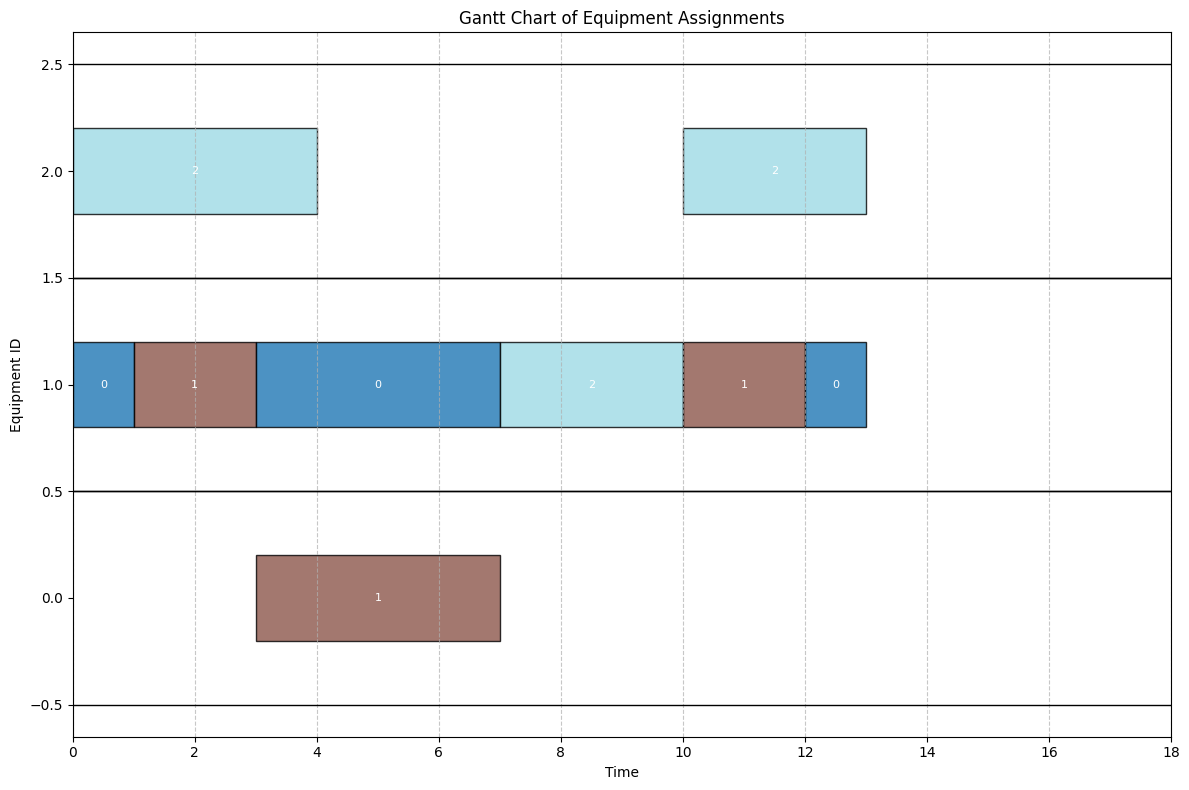

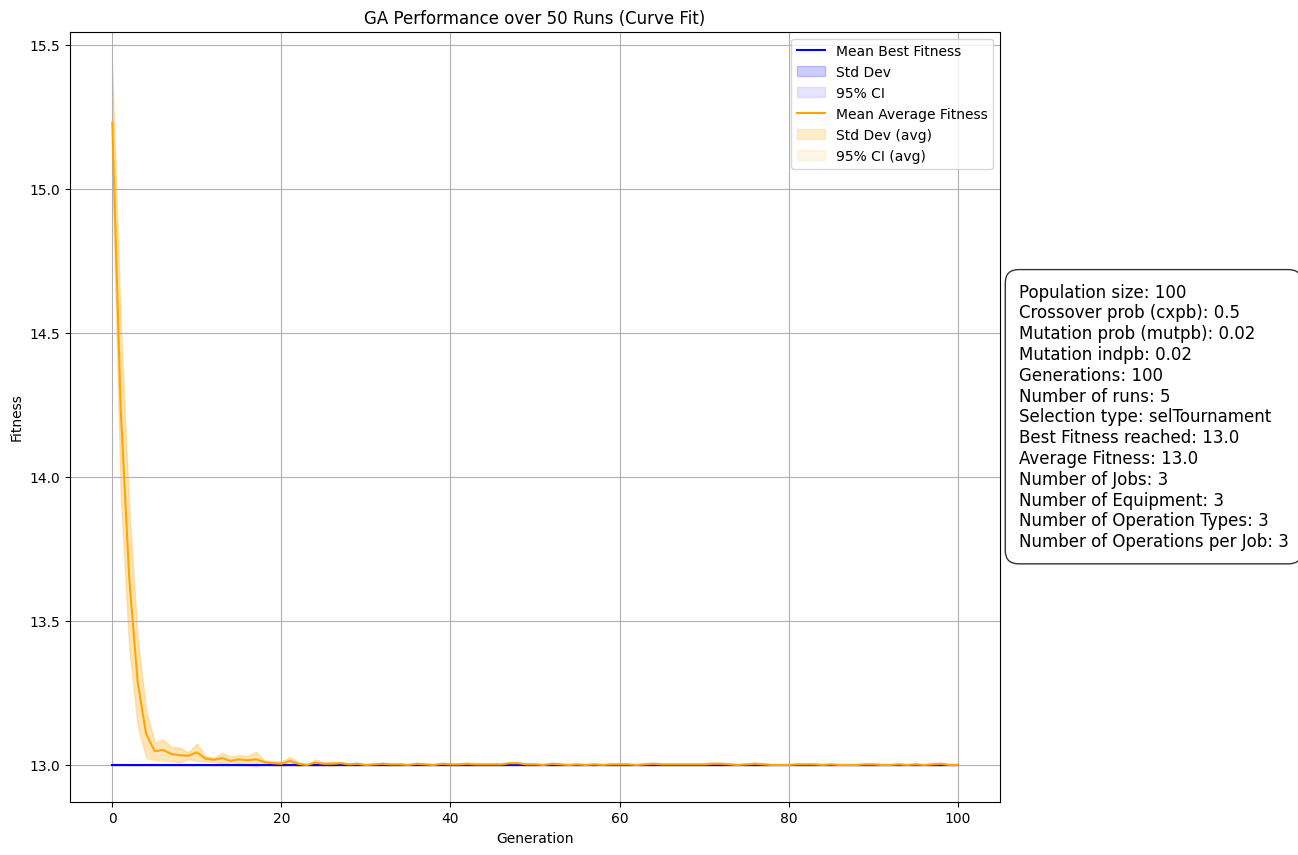

In [143]:
flag = False # flag to control deterministic vs random machine choice in scheduler, True = deterministic, False = random
toolbox = build_ga(gen_individual, fitness_wrapper, config, flag, scheduler_cache)
run_ga_and_plot(toolbox, config, flag, scheduler_cache)